In [ ]:
# Mounting the google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#unzipping the data folder
import shutil
import zipfile
import os
# 1. Clear out the old, messy directory completely
if os.path.exists('/content/GTSRB'):
    shutil.rmtree('/content/GTSRB')

# 2. Extract to the ROOT folder ('/content/'), NOT inside 'Train'
zip_path = '/content/drive/MyDrive/GTSRBDataset/dataset.zip'
data_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_path)

print("Dataset re-extracted cleanly!")


Dataset re-extracted cleanly!


In [ ]:
# Core libraries
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn for data splitting and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# TensorFlow and Keras for deep learning
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,BatchNormalization,Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint

In [ ]:
# Define your dataset path (adjust 'Train' if your extracted folder structure is different)
train_path = '/content/Train'

data = []
labels = []

# Loop through all 43 classes (folders named 0 to 42)
for i in range(43):
    path = os.path.join(train_path, str(i))
    images = os.listdir(path)

    for img_name in images:
        try:
            # Open the image using PIL (which you imported)
            img_path = os.path.join(path, img_name)
            img = Image.open(img_path)

            # Resize to 64x64 (ideal minimum for ResNet50)
            img = img.resize((64, 64))

            # Convert image to a numpy array
            img_array = np.array(img)

            data.append(img_array)
            labels.append(i)
        except Exception as e:
            # Skips system files like .DS_Store if they exist
            continue

# Convert lists into NumPy arrays
X = np.array(data)
y = np.array(labels)

print("Data loading complete!")
print("Images array shape:", X.shape)
print("Labels array shape:", y.shape)


Data loading complete!
Images array shape: (39209, 64, 64, 3)
Labels array shape: (39209,)


In [ ]:
# 1. Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Convert labels to One-Hot Encoded format (e.g., class 3 becomes [0,0,0,1,0,...])
y_train_encoded = to_categorical(y_train, num_classes=43)
y_val_encoded = to_categorical(y_val, num_classes=43)

print("Train images shape:", X_train.shape)
# Expected: (31367, 64, 64, 3)

print("Train labels shape:", y_train_encoded.shape)
# Expected: (31367, 43)

# Paths to your extracted test components
test_csv_path = '/content/Test.csv'
test_folder_path = '/content/'  # Base path because ClassId paths in CSV are relative

# Read the CSV file containing image paths and labels
test_df = pd.read_csv(test_csv_path)

test_data = []
test_labels = []

# Loop through the rows of the CSV file
for index, row in test_df.iterrows():
    try:
        # Get the image path from the CSV and fix it to match your directory structure
        img_path = os.path.join(test_folder_path, row['Path'])
        img = Image.open(img_path)

        # Resize to match training data (64x64)
        img = img.resize((64, 64))
        img_array = np.array(img)

        test_data.append(img_array)
        test_labels.append(row['ClassId'])
    except Exception as e:
        continue

# Convert to NumPy arrays
X_test = np.array(test_data)
y_test = np.array(test_labels)

# One-hot encode the test labels
y_test_encoded = to_categorical(y_test, num_classes=43)

print("Test dataset loaded successfully!")
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test_encoded.shape)


Train images shape: (31367, 64, 64, 3)
Train labels shape: (31367, 43)
Test dataset loaded successfully!
Test images shape: (12630, 64, 64, 3)
Test labels shape: (12630, 43)


In [ ]:
# Training generator
train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    shear_range=0.1,

    fill_mode='nearest'
)

# Validation generator
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Test generator
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow(
    X_train,
    y_train_encoded,
    batch_size=32,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val,
    y_val_encoded,
    batch_size=32,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test,
    y_test_encoded,
    batch_size=32,
    shuffle=False
)

print("Correct ResNet50 preprocessing ready!")


Correct ResNet50 preprocessing ready!


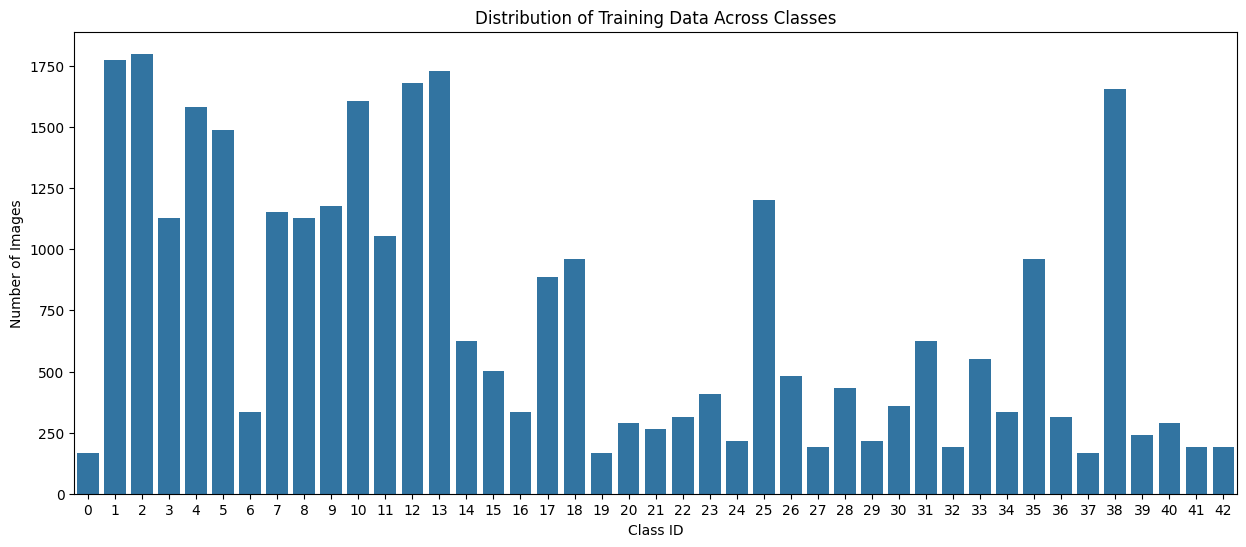

In [ ]:
plt.figure(figsize=(15, 6))
sns.countplot(x=y_train)      # y_train already contains class IDs, no need for argmax
plt.title('Distribution of Training Data Across Classes')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(64,64,3)
)

# Freeze entire ResNet first
base_model.trainable = False

# Custom head
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)

x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(43, activation='softmax')(x)

# Final model
model = Model(
    inputs=base_model.input,
    outputs=outputs
)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1 model ready!")

model.summary()

Phase 1 model ready!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 24,787,371 (94.56 MB)

 Trainable params: 1,195,563 (4.56 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
  1# 1. Configure the callbacks you imported
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,             # Stop training if val_loss doesn't improve for 5 epochs
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,             # Cut learning rate by 80% when stuck
    patience=3,             # Wait 3 epochs before cutting
    min_lr=1e-6
)

# Save best model automatically
checkpoint = ModelCheckpoint(
    'best_resnet50_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
# 2. Launch the training loop using your generators
# We set epochs to 10, but EarlyStopping will likely stop it sooner if it converges
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr,checkpoint],
    verbose=1
)

print("Initial model training is complete!")


Epoch 1/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.0842 - loss: 6.3836
Epoch 1: val_accuracy improved from None to 0.25465, saving model to best_resnet50_model.h5



Epoch 1: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 80ms/step - accuracy: 0.1233 - loss: 5.0867 - val_accuracy: 0.2547 - val_loss: 2.5761 - learning_rate: 1.0000e-05
Epoch 2/8
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2135 - loss: 3.3672
Epoch 2: val_accuracy improved from 0.25465 to 0.35182, saving model to best_resnet50_model.h5



Epoch 2: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.2316 - loss: 3.1410 - val_accuracy: 0.3518 - val_loss: 2.1141 - learning_rate: 1.0000e-05
Epoch 3/8
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2864 - loss: 2.6328
Epoch 3: val_accuracy improved from 0.35182 to 0.43930, saving model to best_resnet50_model.h5



Epoch 3: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 66ms/step - accuracy: 0.3016 - loss: 2.5411 - val_accuracy: 0.4393 - val_loss: 1.8276 - learning_rate: 1.0000e-05
Epoch 4/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3518 - loss: 2.2353
Epoch 4: val_accuracy improved from 0.43930 to 0.50752, saving model to best_resnet50_model.h5



Epoch 4: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 80s 64ms/step - accuracy: 0.3658 - loss: 2.1853 - val_accuracy: 0.5075 - val_loss: 1.5930 - learning_rate: 1.0000e-05
Epoch 5/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4064 - loss: 1.9864
Epoch 5: val_accuracy improved from 0.50752 to 0.56350, saving model to best_resnet50_model.h5



Epoch 5: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.4162 - loss: 1.9453 - val_accuracy: 0.5635 - val_loss: 1.4124 - learning_rate: 1.0000e-05
Epoch 6/8
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4559 - loss: 1.7623
Epoch 6: val_accuracy improved from 0.56350 to 0.62433, saving model to best_resnet50_model.h5



Epoch 6: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 64s 65ms/step - accuracy: 0.4666 - loss: 1.7162 - val_accuracy: 0.6243 - val_loss: 1.2102 - learning_rate: 1.0000e-05
Epoch 7/8
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4988 - loss: 1.6006
Epoch 7: val_accuracy improved from 0.62433 to 0.66960, saving model to best_resnet50_model.h5



Epoch 7: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.5088 - loss: 1.5632 - val_accuracy: 0.6696 - val_loss: 1.0703 - learning_rate: 1.0000e-05
Epoch 8/8
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5380 - loss: 1.4350
Epoch 8: val_accuracy improved from 0.66960 to 0.71232, saving model to best_resnet50_model.h5



Epoch 8: finished saving model to best_resnet50_model.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.5505 - loss: 1.4073 - val_accuracy: 0.7123 - val_loss: 0.9370 - learning_rate: 1.0000e-05
Initial model training is complete!


In [ ]:
model.load_weights("best_resnet50_model.h5")

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# fine tuning
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

NameError: name 'early_stopping' is not defined

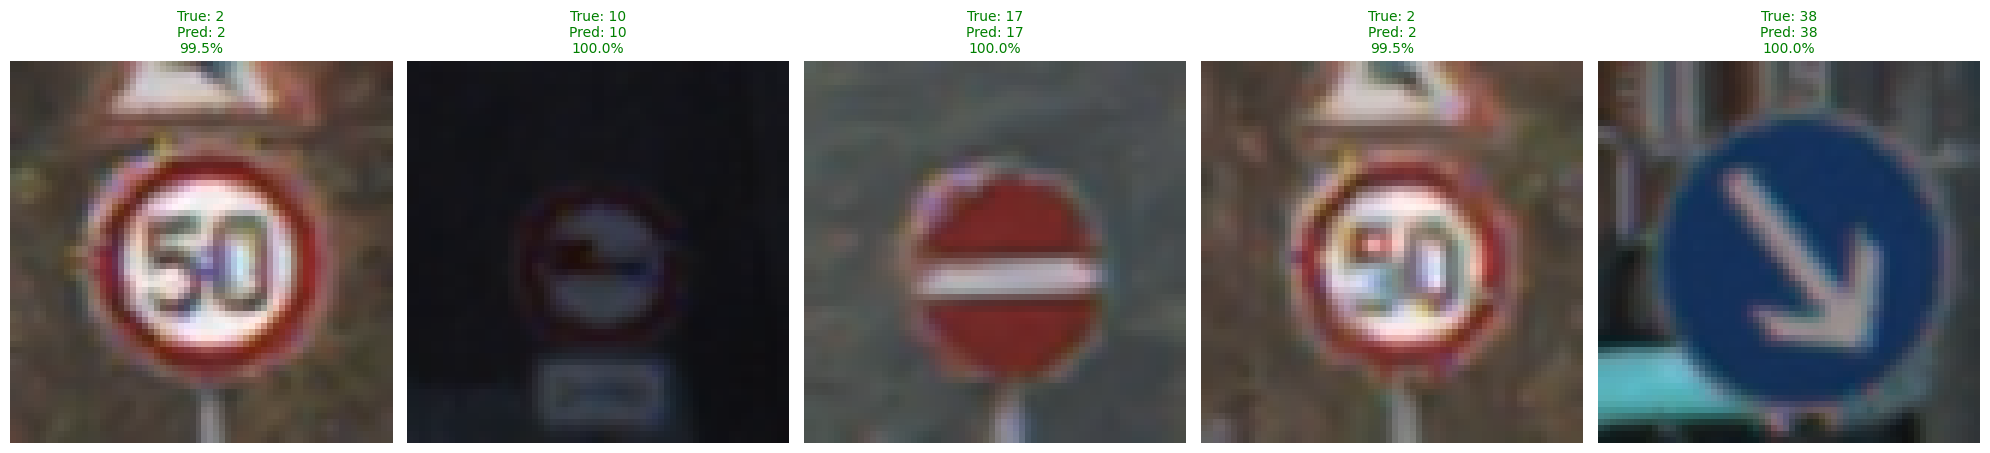

In [ ]:
def visualize_random_predictions(model,X_test,y_test,num_samples=5):

    # Create subplot grid
    plt.figure(figsize=(20,5))

    for i in range(num_samples):

        idx = random.randint(0, len(X_test) - 1)

        sample_image = X_test[idx]

        true_label = y_test[idx]

        input_image = np.expand_dims(sample_image, axis=0)

        input_image = preprocess_input(input_image.copy())

        preds = model.predict(input_image, verbose=0)

        predicted_class = np.argmax(preds)

        confidence = np.max(preds) * 100

        plt.subplot(1, num_samples, i + 1)

        plt.imshow(sample_image.astype("uint8"))

        # Green = correct prediction
        # Red = wrong prediction
        color = (
            'green'
            if predicted_class == true_label
            else 'red'
        )

        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_class}\n"
            f"{confidence:.1f}%",
            color=color,
            fontsize=10
        )

        plt.axis('off')

    plt.tight_layout()

    plt.show()
# RUN VISUALIZATION
visualize_random_predictions(model,X_test,y_test,num_samples=5)

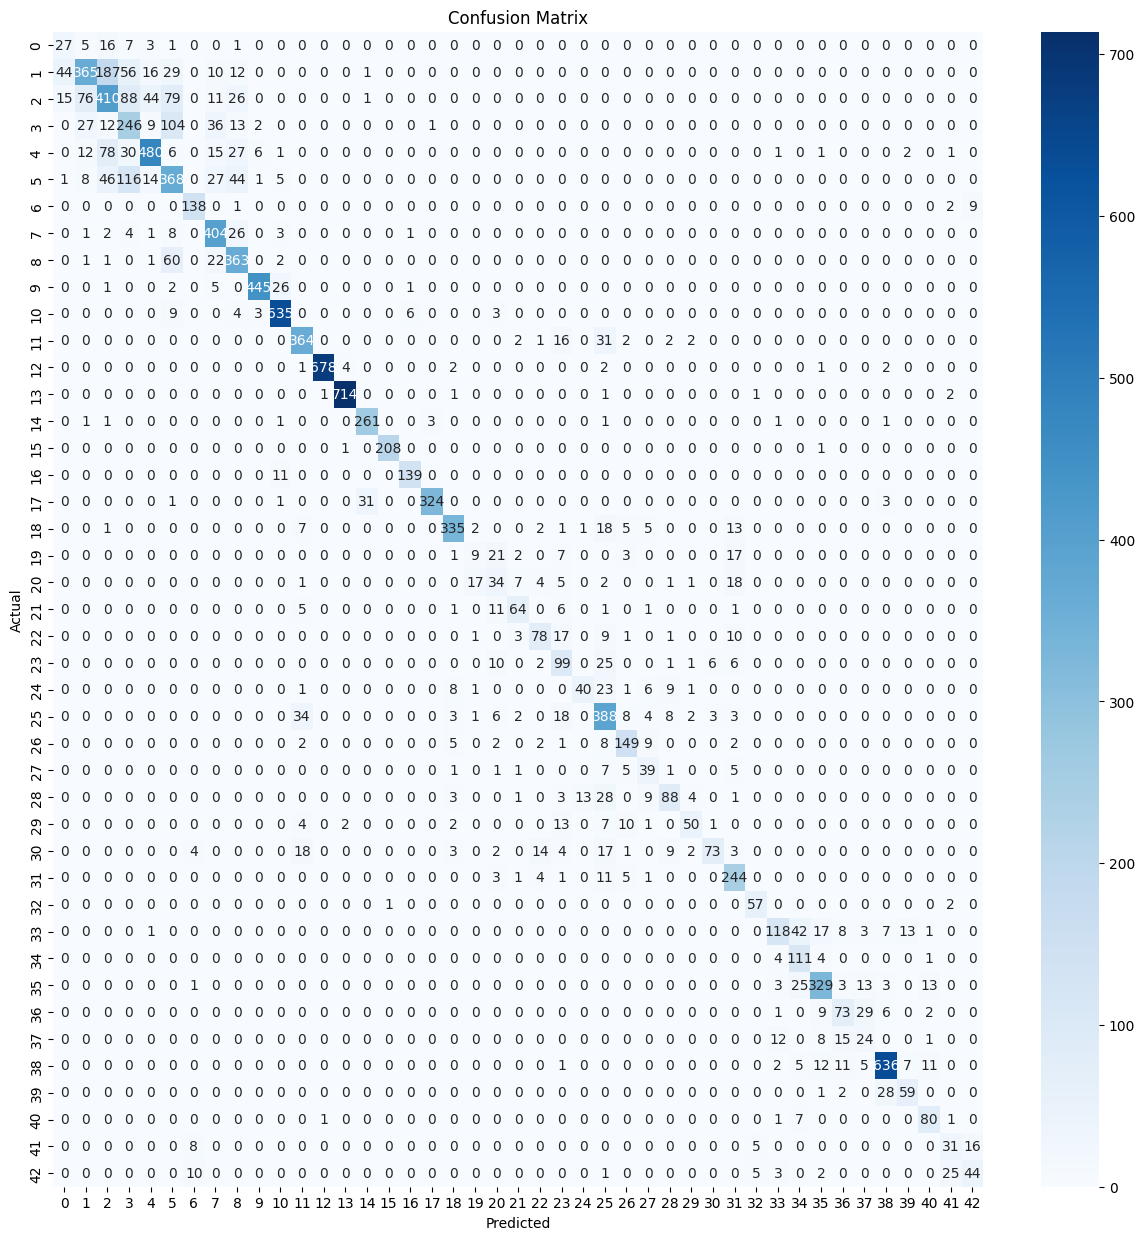

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(15,15))

sns.heatmap(cm, cmap='Blues',annot=True,fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()